In [2]:
# Cell 1: Imports
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
import joblib

# try imports that may not be installed in minimal envs
try:
    from xgboost import XGBClassifier
except Exception as e:
    raise ImportError('xgboost is required: '+str(e))

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline
except Exception as e:
    raise ImportError('imbalanced-learn is required: '+str(e))

# plotting & metrics
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, balanced_accuracy_score, f1_score, roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score
%matplotlib inline

In [3]:
# Cell 2: Locate dataset (robust search through parents)
project_root = Path.cwd()
data_path = None
for parent in [project_root] + list(project_root.parents):
    candidate = parent / 'Data' / 'Numerical' / 'Data' / '65_Nutrients_Data.csv'
    if candidate.exists():
        data_path = candidate
        project_root = parent
        break

if data_path is None:
    raise FileNotFoundError('Could not find 65_Nutrients_Data.csv under any parent of '+str(Path.cwd()))

print('Using data file:', data_path)
df = pd.read_csv(data_path)
print('df shape:', df.shape)
if 'novaclass' not in df.columns:
    raise KeyError('novaclass column missing in dataset')

X = df.drop(columns=['novaclass'])
y = df['novaclass'].astype(int)
min_label = int(y.min())
if min_label != 0:
    y = y - min_label
    print('Shifted labels by', min_label)

Using data file: c:\Users\Divyeh\OneDrive\Desktop\ML_IP\NOVA_Food_Processing\Data\Numerical\Data\65_Nutrients_Data.csv
df shape: (2970, 66)
Shifted labels by 1


In [4]:
# Cell 3: Train/test split and pipeline definition
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('train/test sizes', X_train.shape, X_test.shape)

sm = SMOTE(random_state=42)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
pipe = Pipeline([('smote', sm), ('xgb', xgb)])

param_dist = {
    'xgb__n_estimators': [100,200,400],
    'xgb__max_depth': [3,4,6],
    'xgb__learning_rate': [0.01,0.05,0.1],
    'xgb__subsample': [0.6,0.8,1.0],
    'xgb__colsample_bytree': [0.6,0.8,1.0],
    'xgb__gamma': [0,1],
    'xgb__reg_alpha':[0,0.1],
    'xgb__reg_lambda':[1,0.1]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
from sklearn.model_selection import RandomizedSearchCV
rs = RandomizedSearchCV(pipe, param_distributions=param_dist, n_iter=20, scoring='f1_macro', cv=cv, n_jobs=-1, random_state=42, verbose=1, return_train_score=True)

print('Starting RandomizedSearchCV (20 trials)')
rs.fit(X_train, y_train)
print('Done. Best CV f1_macro:', rs.best_score_)
print('Best params:', rs.best_params_)
best = rs.best_estimator_
cvres = rs.cv_results_

train/test sizes (2376, 65) (594, 65)
Starting RandomizedSearchCV (20 trials)
Fitting 5 folds for each of 20 candidates, totalling 100 fits


KeyboardInterrupt: 

In [ ]:
# Cell 4: Evaluate and save best estimator
from sklearn.metrics import classification_report, balanced_accuracy_score, f1_score, roc_auc_score
y_pred = best.predict(X_test)
print('\nClassification report on test set:')
print(classification_report(y_test, y_pred))
print('balanced accuracy:', balanced_accuracy_score(y_test, y_pred))
print('f1_macro:', f1_score(y_test, y_pred, average='macro'))

# ROC AUC (OVO macro) if probability available
classes = np.unique(y_train)
try:
    y_test_bin = (y_test.values.reshape(-1,1) == classes.reshape(1,-1)).astype(int)
    y_score = best.predict_proba(X_test)
    print('roc_auc_ovo_macro:', roc_auc_score(y_test_bin, y_score, average='macro', multi_class='ovo'))
except Exception as e:
    print('roc_auc error:', e)

out_dir = project_root / 'models' / 'numerical_65_xgb' / 'smote'
out_dir.mkdir(parents=True, exist_ok=True)
model_file = out_dir / 'xgb_65_numerical_smote.joblib'
joblib.dump(best, model_file)
print('Saved model to', model_file)


Classification report on test set:
              precision    recall  f1-score   support

           0       0.80      0.87      0.83        68
           1       0.75      0.82      0.78        11
           2       0.79      0.77      0.78        93
           3       0.96      0.95      0.96       422

    accuracy                           0.91       594
   macro avg       0.83      0.85      0.84       594
weighted avg       0.91      0.91      0.91       594

balanced accuracy: 0.8525648480542722
f1_macro: 0.8380257969019486
roc_auc_ovo_macro: 0.9813259525254281
Saved model to c:\Users\Divyeh\OneDrive\Desktop\ML_IP\NOVA_Food_Processing\models\numerical_65_xgb\smote\xgb_65_numerical_smote.joblib


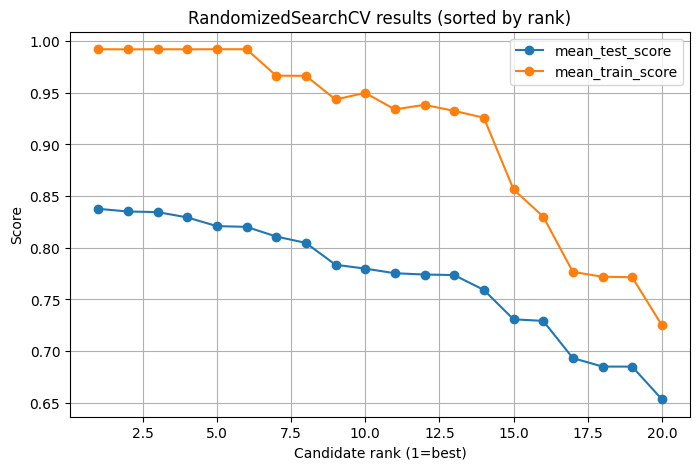

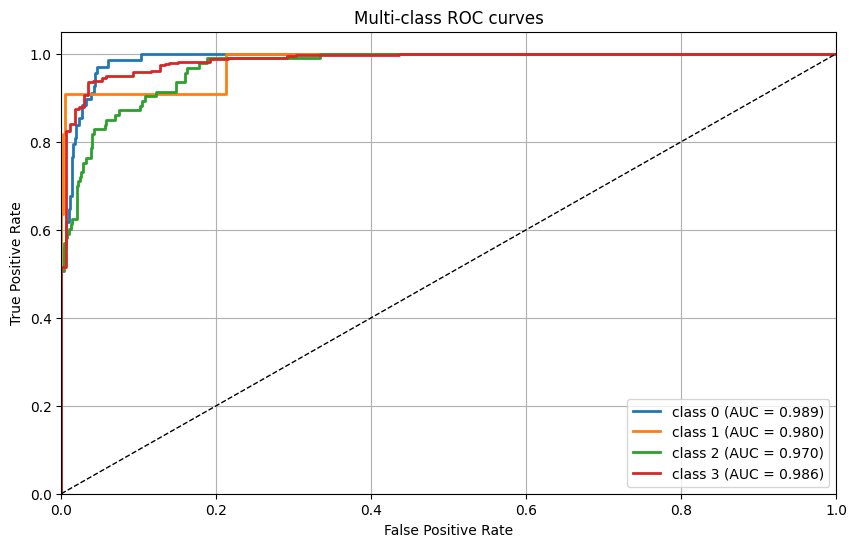

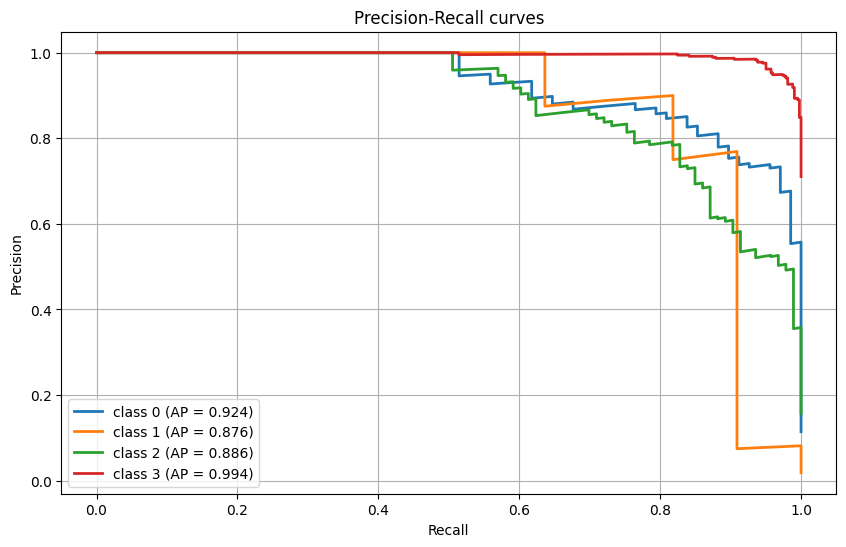

In [ ]:
# Cell 5: Plot CV results and ROC/PR curves
import pandas as _pd
cv_df = _pd.DataFrame(cvres)
cv_df = cv_df.sort_values('rank_test_score')
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cv_df)+1), cv_df['mean_test_score'], marker='o', label='mean_test_score')
if 'mean_train_score' in cv_df.columns:
    plt.plot(range(1, len(cv_df)+1), cv_df['mean_train_score'], marker='o', label='mean_train_score')
plt.xlabel('Candidate rank (1=best)')
plt.ylabel('Score')
plt.title('RandomizedSearchCV results (sorted by rank)')
plt.legend()
plt.grid(True)
plt.show()

# ROC and Precision-Recall curves
from sklearn.preprocessing import label_binarize
n_classes = len(np.unique(y))
y_score = None
try:
    y_score = best.predict_proba(X_test)
except Exception as e:
    print('predict_proba not available:', e)

if y_score is not None:
    y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))
    plt.figure(figsize=(10,6))
    fpr = dict(); tpr = dict(); roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], lw=2, label=f'class {i} (AUC = {roc_auc[i]:0.3f})')
    plt.plot([0,1], [0,1], 'k--', lw=1)
    plt.xlim([0.0,1.0]); plt.ylim([0.0,1.05])
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title('Multi-class ROC curves')
    plt.legend(loc='lower right')
    plt.grid(True); plt.show()

    # Precision-Recall per class
    plt.figure(figsize=(10,6))
    precision = dict(); recall = dict(); ap = dict()
    for i in range(n_classes):
        precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_score[:, i])
        ap[i] = average_precision_score(y_test_bin[:, i], y_score[:, i])
        plt.plot(recall[i], precision[i], lw=2, label=f'class {i} (AP = {ap[i]:0.3f})')
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title('Precision-Recall curves')
    plt.legend(loc='lower left')
    plt.grid(True); plt.show()
else:
    print('Skipping ROC/PR plots because probability estimates are unavailable.')

In [ ]:
# Cell 5: Load saved model and quick inspect
from pprint import pprint
saved = out_dir / 'xgb_65_numerical_smote.joblib'
if not saved.exists():
    raise FileNotFoundError('Saved model not found: '+str(saved))
loaded = joblib.load(saved)
print('Loaded object type:', type(loaded))
# show pipeline steps and xgb params
try:
    pprint(dict(loaded.named_steps['xgb'].get_params()))
except Exception:
    pprint(loaded)

# Predict on the test set to confirm load
y_pred2 = loaded.predict(X_test)
print('f1_macro (loaded):', f1_score(y_test, y_pred2, average='macro'))

Loaded object type: <class 'imblearn.pipeline.Pipeline'>
{'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 0.6,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'mlogloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': 0,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.1,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 6,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 200,
 'n_jobs': None,
 'num_parallel_tree': None,
 'objective': 'multi:softprob',
 'random_state': 42,
 'reg_alpha': 0,
 'reg_lambda': 0.1,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': 1.0,
 'tree_method': None,
 'use_label_encoder': False,
 'validate_

In [2]:
# Cell: Install catboost into the notebook kernel
import sys
import subprocess
try:
    print('Installing catboost into:', sys.executable)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade', 'pip'])
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'catboost'])
    print('catboost installed successfully. Please restart the kernel and re-run the CatBoost evaluation cell.')
except Exception as e:
    print('Installation failed:', e)

Installing catboost into: c:\Program Files\Python313\python.exe
catboost installed successfully. Please restart the kernel and re-run the CatBoost evaluation cell.
